# Phase 4 — Clustering (K-Means Soil Zoning)
**AgroSense AI Pipeline**

Goals:
- Determine optimal k using Elbow + Silhouette
- Train K-Means with k=6
- Profile each soil cluster
- Visualise clusters with PCA
- Map clusters to agronomic zone names

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster     import KMeans
from sklearn.metrics     import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})

with open('processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_scaled = data['X_scaled']
df       = data['df_clean']
FEATURES = data['features']
print(f'Loaded {X_scaled.shape[0]} samples for clustering.')

Loaded 2200 samples for clustering.


## 4.1  Elbow Method + Silhouette Score

In [2]:
K_RANGE = range(2, 13)
inertia, silhouette, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'k={k:2d}: inertia={km.inertia_:,.0f}  silhouette={silhouette[-1]:.4f}  DB={db_scores[-1]:.4f}')

k= 2: inertia=20,608  silhouette=0.2270  DB=1.8274
k= 3: inertia=16,694  silhouette=0.2743  DB=1.4667
k= 4: inertia=14,272  silhouette=0.2670  DB=1.4374
k= 5: inertia=12,258  silhouette=0.2849  DB=1.3227
k= 6: inertia=10,747  silhouette=0.3156  DB=1.1800
k= 7: inertia=9,481  silhouette=0.3247  DB=1.1618
k= 8: inertia=8,730  silhouette=0.3266  DB=1.2062
k= 9: inertia=8,085  silhouette=0.3311  DB=1.1729
k=10: inertia=7,511  silhouette=0.3403  DB=1.1391
k=11: inertia=7,060  silhouette=0.3449  DB=1.0978
k=12: inertia=6,665  silhouette=0.3446  DB=1.1580


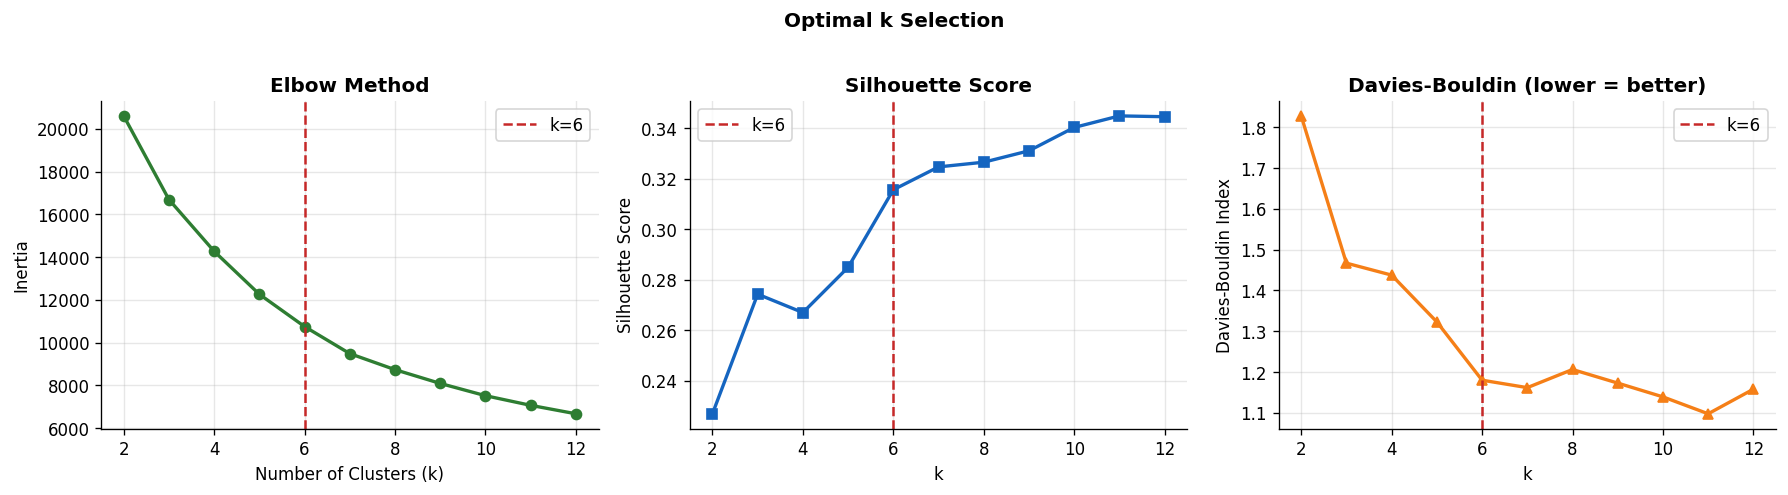

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_RANGE, inertia, 'o-', color='#2E7D32', linewidth=2)
axes[0].axvline(6, color='#C62828', linestyle='--', linewidth=1.5, label='k=6')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend()

axes[1].plot(K_RANGE, silhouette, 's-', color='#1565C0', linewidth=2)
axes[1].axvline(6, color='#C62828', linestyle='--', linewidth=1.5, label='k=6')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].legend()

axes[2].plot(K_RANGE, db_scores, '^-', color='#F57F17', linewidth=2)
axes[2].axvline(6, color='#C62828', linestyle='--', linewidth=1.5, label='k=6')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin (lower = better)', fontweight='bold')
axes[2].legend()

plt.suptitle('Optimal k Selection', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/phase4_optimal_k.png', bbox_inches='tight')
plt.show()

## 4.2  Train Final K-Means (k=6)

In [4]:
K_FINAL = 6
kmeans  = KMeans(n_clusters=K_FINAL, n_init=25, random_state=42)
labels  = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, labels)
db  = davies_bouldin_score(X_scaled, labels)
ch  = calinski_harabasz_score(X_scaled, labels)

print(f'k={K_FINAL} metrics:')
print(f'  Silhouette Score:          {sil:.4f}')
print(f'  Davies-Bouldin Index:      {db:.4f}  (lower is better)')
print(f'  Calinski-Harabasz Score:   {ch:.1f}  (higher is better)')
print(f'  Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True)))}')

k=6 metrics:
  Silhouette Score:          0.3156
  Davies-Bouldin Index:      1.1800  (lower is better)
  Calinski-Harabasz Score:   639.1  (higher is better)
  Cluster sizes: {np.int32(0): np.int64(100), np.int32(1): np.int64(523), np.int32(2): np.int64(484), np.int32(3): np.int64(200), np.int32(4): np.int64(269), np.int32(5): np.int64(624)}


## 4.3  Cluster Profiles

In [5]:
df_cluster = df.copy()
df_cluster['cluster'] = labels

ZONE_NAMES = {
    0: 'Sandy Loam',    1: 'Clay-Rich',     2: 'Balanced Loam',
    3: 'Acidic Red',    4: 'Saline',        5: 'Nutrient-Rich Black',
}

# Auto-assign zone names by centroid characteristics
centroids_raw = kmeans.cluster_centers_
scaler = data['scaler']
centroids_orig = scaler.inverse_transform(
    centroids_raw[:, :len(FEATURES)] if centroids_raw.shape[1] > len(FEATURES)
    else centroids_raw
)

centroid_df = pd.DataFrame(centroids_orig, columns=FEATURES[:centroids_orig.shape[1]])
centroid_df.index.name = 'Cluster'
print('Cluster centroids (original scale):')
print(centroid_df.round(2))

ValueError: operands could not be broadcast together with shapes (6,7) (12,) (6,7) 

In [ ]:
# Cluster profile heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(centroid_df.T, annot=True, fmt='.1f', cmap='Greens',
            linewidths=0.5, ax=ax,
            xticklabels=[f'C{i}' for i in range(K_FINAL)])
ax.set_title('Cluster Centroid Profiles', fontweight='bold', pad=12)
ax.set_ylabel('Feature')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('outputs/phase4_cluster_profiles.png', bbox_inches='tight')
plt.show()

## 4.4  PCA Visualisation

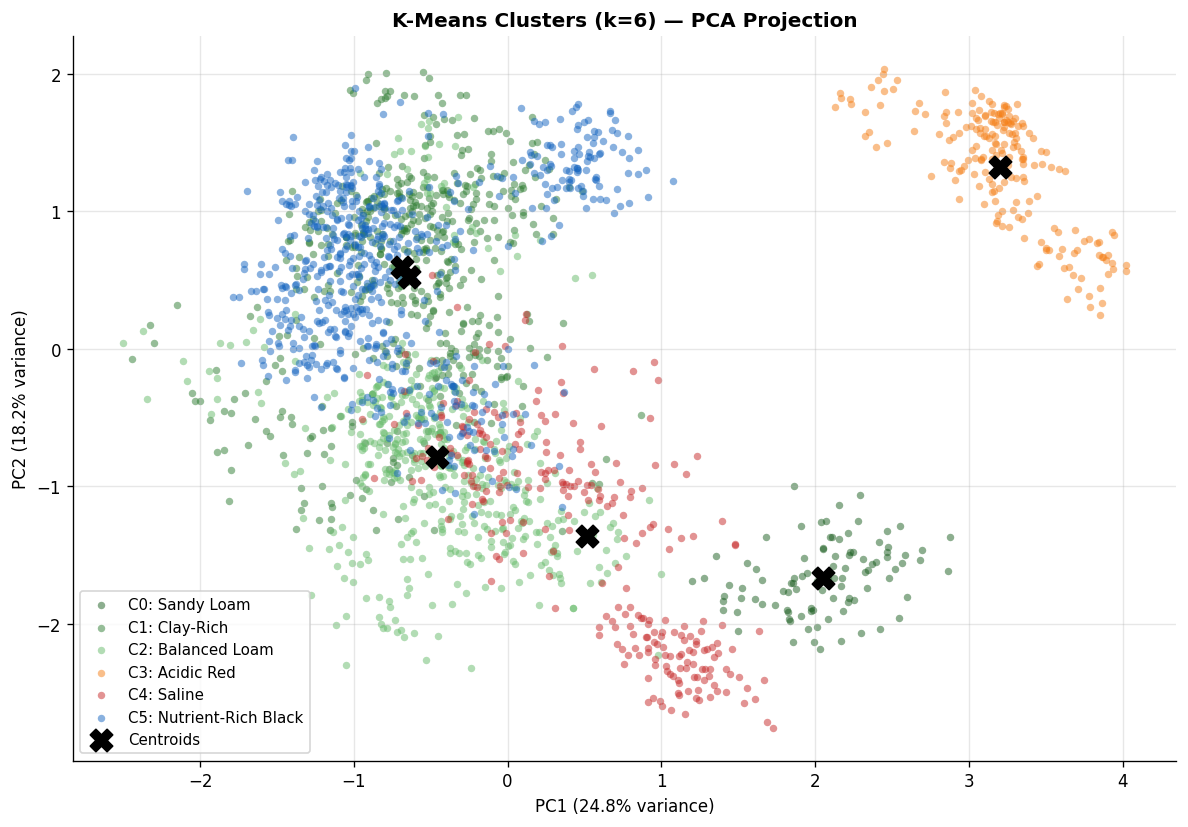

Total variance explained by 2 PCs: 43.1%


In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled[:, :len(FEATURES)])
var_explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1B5E20','#2E7D32','#66BB6A','#F57F17','#C62828','#1565C0']

for cluster_id in range(K_FINAL):
    mask = labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cluster_id], label=f'C{cluster_id}: {ZONE_NAMES.get(cluster_id,"Zone")}',
               alpha=0.5, s=20, linewidths=0)

# Plot centroids
centroids_pca = pca.transform(centroids_raw[:, :len(FEATURES)])
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=180, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
ax.set_title(f'K-Means Clusters (k={K_FINAL}) — PCA Projection', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/phase4_clusters_pca.png', bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {sum(var_explained)*100:.1f}%')

## 4.5  Crop Distribution per Cluster

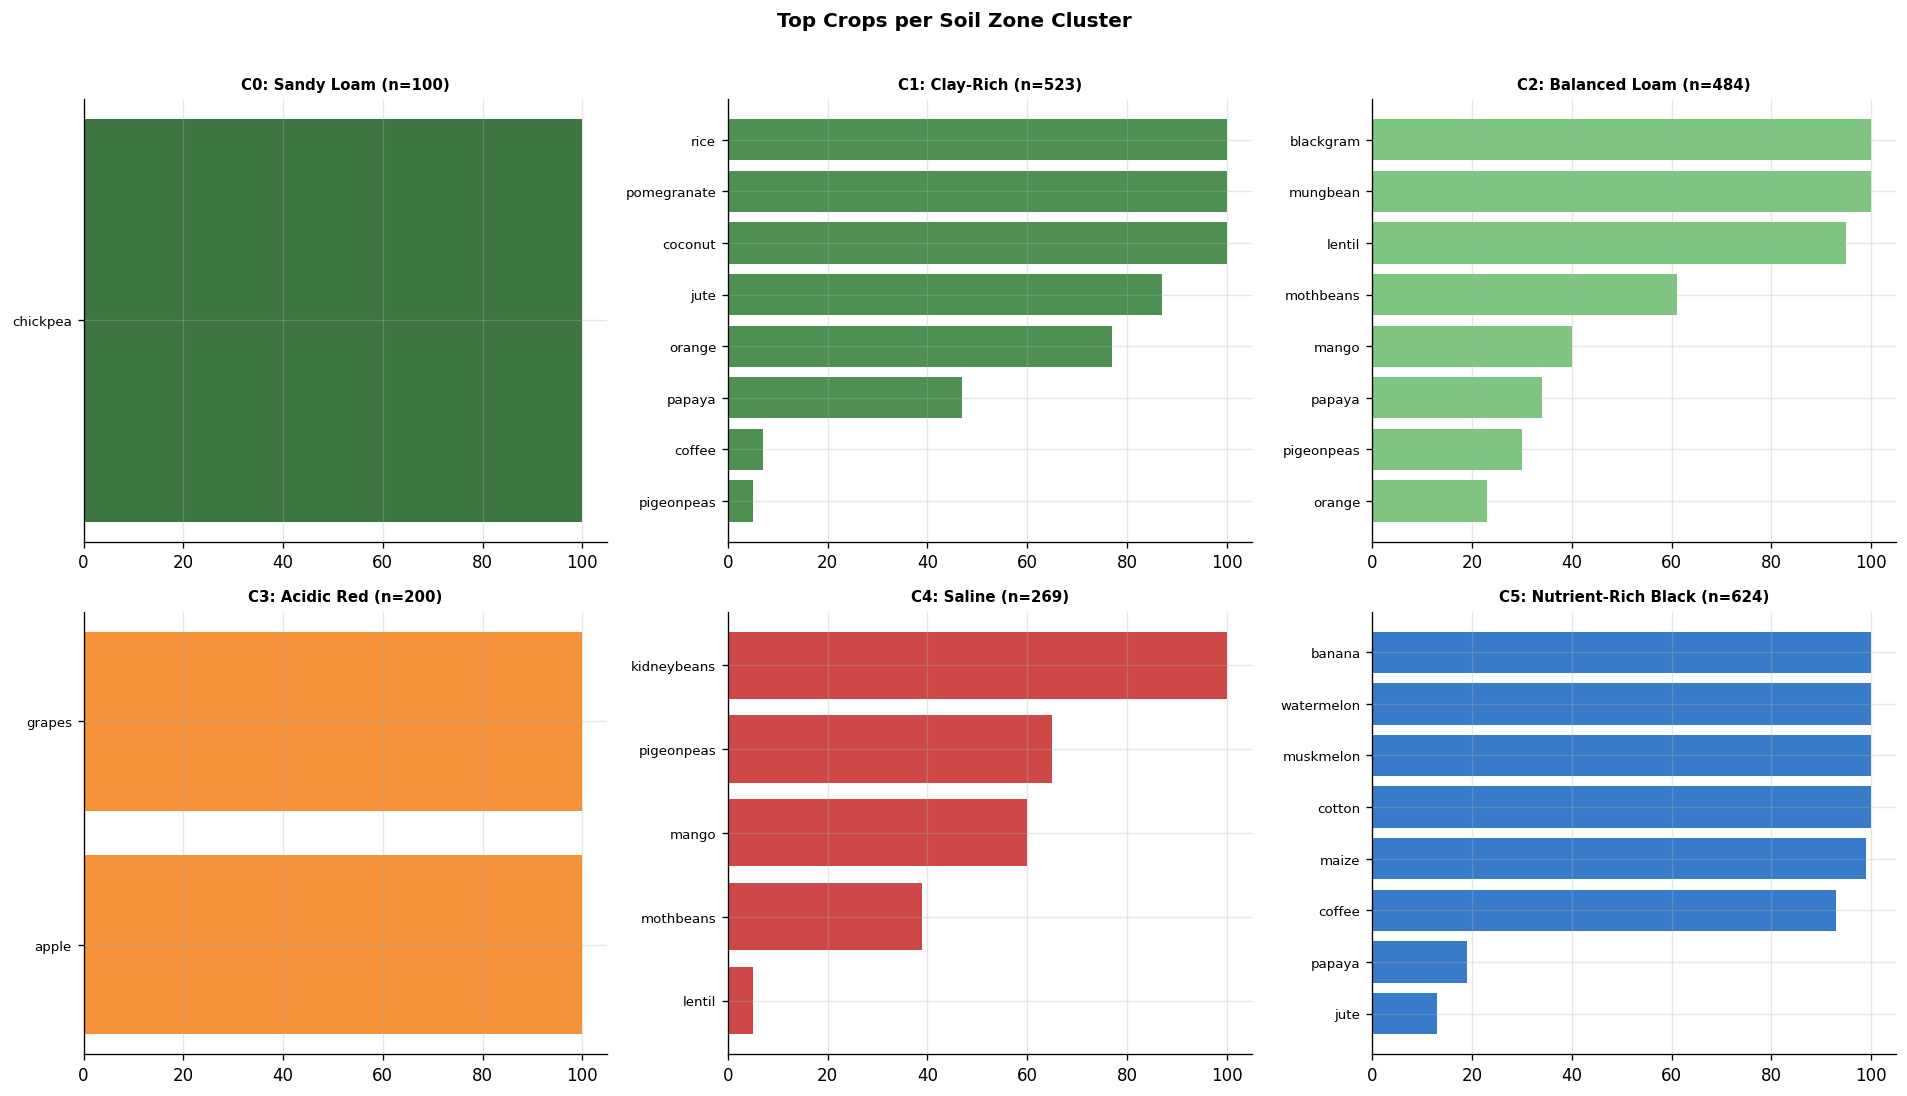

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for c_id in range(K_FINAL):
    subset = df_cluster[df_cluster['cluster'] == c_id]
    counts = subset['label'].value_counts().head(8)
    axes[c_id].barh(counts.index[::-1], counts.values[::-1],
                    color=colors[c_id], alpha=0.85)
    axes[c_id].set_title(f'C{c_id}: {ZONE_NAMES.get(c_id,"")} (n={len(subset)})',
                          fontweight='bold', fontsize=9)
    axes[c_id].tick_params(axis='y', labelsize=8)

plt.suptitle('Top Crops per Soil Zone Cluster', fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase4_cluster_crops.png', bbox_inches='tight')
plt.show()

## 4.6  Save

In [8]:
data['kmeans']     = kmeans
data['cluster_labels'] = labels
data['zone_names'] = ZONE_NAMES

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print('K-Means model saved to processed_data.pkl')

K-Means model saved to processed_data.pkl
